In [1]:
import os
import re
import matplotlib.pyplot as plt
import pandas as pd
import json
import sys
sys.path.append('../src') 

from collections import Counter
from langchain_text_splitters import RecursiveCharacterTextSplitter
from data_utils import create_documents_from_xml

In [2]:
root_dir = "documents/RU-DE/special language/press-sociopolitical/WHO/News WHO Europe"
root_dir = "documents"
raw_documents, files = create_documents_from_xml(root_dir)

file_to_save = "data/file_mapping.json"
file_mapping_json = json.dumps(files, ensure_ascii=False)

with open(file_to_save, "w") as f:
    f.write(file_mapping_json)

print(f"Saved file mapping to {file_to_save}: {len(file_mapping_json):,} chars to {os.path.getsize(file_to_save):,} bytes.")
print(f"Total files parsed: {len(files):,}")
print(f"Total documents created: {len(raw_documents):,}")

Saved file mapping to data/file_mapping.json: 43,921 chars to 52,361 bytes.
Total files parsed: 251
Total documents created: 231,377


In [3]:
df = pd.DataFrame(raw_documents)
print(f"From {len(raw_documents):,} raw_documents created DataFrame with {len(df):,} items.")

From 231,377 raw_documents created DataFrame with 231,377 items.


In [4]:
def get_augmented_data(data_frame):
    copy_df = data_frame.copy()
    temp = copy_df['text']
    copy_df['text'] = copy_df['tr_text']
    copy_df['tr_text'] = temp
    
    temp = copy_df['lang']
    copy_df['lang'] = copy_df['tr_lang']
    copy_df['tr_lang'] = temp
    
    return copy_df

augmented_df = get_augmented_data(df)
print(f"Created augmented df: {len(augmented_df):,}")

df = pd.concat([df, augmented_df], ignore_index=True)
print(f"Concated df and augmented_df: {len(df):,}")

Created augmented df: 231,377
Concated df and augmented_df: 462,754


In [5]:
def convert_to_lower_case():
    cols = ['text']
    for col in cols:
        df[col] = df[col].str.lower()
    print(f"Converted texts to lower case: {len(df):,}")

convert_to_lower_case()

Converted texts to lower case: 462,754


In [6]:
noise_pattern = r"[^\w .,:;!?]"
noise = set()
def clean_noise():
    def clean_and_collect(text):
        matches = re.findall(noise_pattern, text)
        noise.update(matches)
        cleaned = re.sub(noise_pattern, '', text)
        return cleaned
    
    cols = ['text', 'tr_text']
    for col in cols:
        df[col] = df[col].apply(clean_and_collect)

clean_noise()
print(f"Cleaned noise from texts: {len(df):,}")

print(f"\nCleaned noise:\n{noise}") 

Cleaned noise from texts: 462,754

Cleaned noise:
{'»', '\u2009', '‑', '§', '′', '´', '\u2005', '`', '̕', '~', '́', '\uf0a7', '‘', '►', '^', '¬', '\t', '−', '‚', ')', '†', '›', '‟', '’', '≤', '$', '>', '&', '—', '£', ']', '̈', '·', "'", '\u2028', '=', '"', '{', '™', '\u200a', '̌', '<', '→', '”', '%', '×', '±', '“', '\u202f', '-', '*', '№', '\n', '©', '•', '\\', '‹', '}', '®', '„', '(', '‒', '€', '\u200e', '□', '➜', '●', '\u200b', '\xa0', '\x84', '∙', '◦', '″', '[', '▪', '+', '°', '«', '…', '|', '/', '@', '#', '\xad', '–', '≥'}


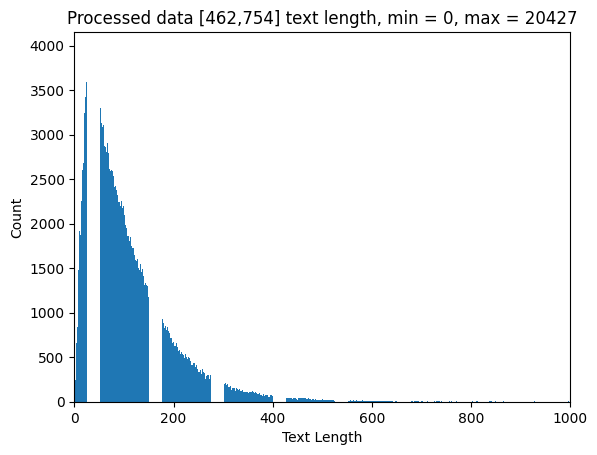

In [7]:
lengths = [len(row['text']) for _, row in df.iterrows()]
counter = Counter(lengths)

plt.bar(counter.keys(), counter.values())
plt.xlim(0, 1000)
plt.xlabel("Text Length")
plt.ylabel("Count")
plt.title(f"Processed data [{len(lengths):,}] text length, min = {min(counter)}, max = {max(counter)}")
plt.show()

In [8]:
min_len = 50
max_len = 200

filtered_df = df[df['text'].str.len() <= max_len]
print(f"Size of filtered_df: [{len(filtered_df):,} / {len(df):,}]")

Size of filtered_df: [406,202 / 462,754]


In [9]:
def clean_text(text):
    cleaned = re.sub(r"[0-9.,:;!?]", "", text).strip()
    return cleaned
filtered_df['text'] = filtered_df['text'].apply(clean_text)
print(f"Number of filtered_df: [{len(filtered_df):,} / {len(df):,}]")

Number of filtered_df: [406,202 / 462,754]


In [10]:
ready_df = filtered_df[filtered_df['text'].str.len() >= min_len]
print(f"Size of ready_df: [{len(ready_df):,} / {len(df):,}]")

Size of ready_df: [253,263 / 462,754]


In [11]:
sampled = ready_df.sample(n=3)["text"].to_list()
for s in sampled:
    print(f"- {s}")

- крестьяне больше верили соглашательской партии эсеров чем настоящим революционерам  большевикамврезультате борьба крестьян против помещиков была недостаточно организована
- nachdem er sein bett bezogen hatte setzte er sich darauf und sah zu seinem zellengenossen hin
- но вот и голос диктора читающего метеорологическую сводку погода и в дальнейшем не обещает ничего утешительного


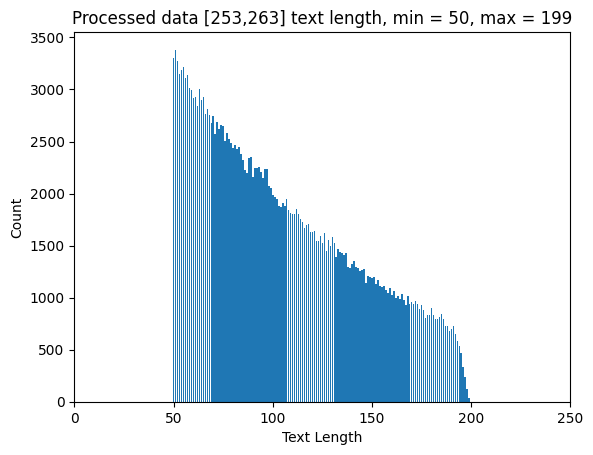

In [12]:
lengths = [len(row['text']) for _, row in ready_df.iterrows()]
counter = Counter(lengths)

plt.bar(counter.keys(), counter.values())
plt.xlim(0, 250)
plt.xlabel("Text Length")
plt.ylabel("Count")
plt.title(f"Processed data [{len(lengths):,}] text length, min = {min(counter)}, max = {max(counter)}")
plt.show()

In [13]:
big_df = df[df['text'].str.len() > max_len]
small_df = df[df['text'].str.len() < min_len]

print(f"{'Noiseless df:':<20} {len(df):>10,}")
print(f"{'Ready df:':<20} {len(ready_df):>10,}  {min_len} <= len <= {max_len}")
print(f"{'Big df:':<20} {len(big_df):>10,}  len > {max_len}")
print(f"{'Small df:':<20} {len(small_df):>10,}  len < {min_len}")
print(f"\nFiltered [{len(filtered_df):,}] + big [{len(big_df):,}] + small [{len(small_df):,}] = \
[{len(ready_df) + len(big_df) + len(small_df):,} / {len(df):,}]")

print(f"Filtered + big: {len(filtered_df) + len(big_df):,}")
print(f"Filtered - ready: {len(filtered_df) - len(ready_df):,}")

Noiseless df:           462,754
Ready df:               253,263  50 <= len <= 200
Big df:                  56,552  len > 200
Small df:               144,811  len < 50

Filtered [406,202] + big [56,552] + small [144,811] = [454,626 / 462,754]
Filtered + big: 462,754
Filtered - ready: 152,939


In [14]:
sampled = big_df.sample(n=3)["text"].to_list()
for s in sampled:
    print(f"- {s}")

- a der untergeneralsekretär für management kann nach einer umfassenden untersuchung die abschreibung von barmittelverlusten und des buchwerts von forderungen und wechselforderungen, die für uneinbringlich gehalten werden, genehmigen.
- порцию песка как правило 14 г стандартного песка i в соответствии с din 1164 рассыпают на сухой, чистой испытуемой поверхности и при помощи диска из твердого дерева или твердой резины без давления кругообразными движениями распределяют по поверхности до образования круглого пятна, не подлежащего дальнейшему расширению.
- внешнеэкономическая либерализация и введение ордолиберального рыночного хозяйства угрожают привилегиям тех, кто раньше выигрывал от автократии и rentismo явление, типичное для латинской америки: продажапередача своих прав на чтолибо: прав на землю, на пользование полезными ископаемыми, добычу нефти и т.д.  на условиях ренты; как правило, сопровождается обманом населения и коррупциейприм. пер. .


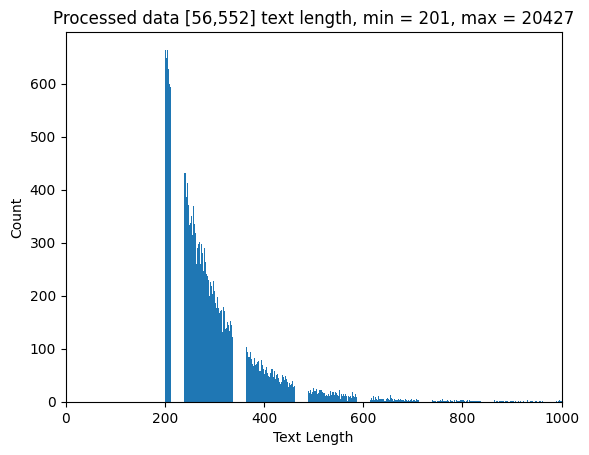

In [15]:
lengths = [len(row['text']) for _, row in big_df.iterrows()]
counter = Counter(lengths)

plt.bar(counter.keys(), counter.values())
plt.xlim(0, 1000)
plt.xlabel("Text Length")
plt.ylabel("Count")
plt.title(f"Processed data [{len(lengths):,}] text length, min = {min(counter)}, max = {max(counter)}")
plt.show()

In [16]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=200, 
    chunk_overlap=20,
    separators = [
        "\n\n",
        "\n",
        ". ",
        "... ",
        "! ",
        "? ",
        "; ",
        ": ",
        ", ",
        " ",
    ]
)
def split_text(text):
    return splitter.split_text(text)

splitted_big_df = big_df.copy()
splitted_big_df['text'] = splitted_big_df['text'].apply(split_text)
splitted_big_df = splitted_big_df.explode('text', ignore_index=True)
    
print(f"From all {len(big_df):,} big_df {len(splitted_big_df):,} splitted_big_df created.")

From all 56,552 big_df 142,566 splitted_big_df created.


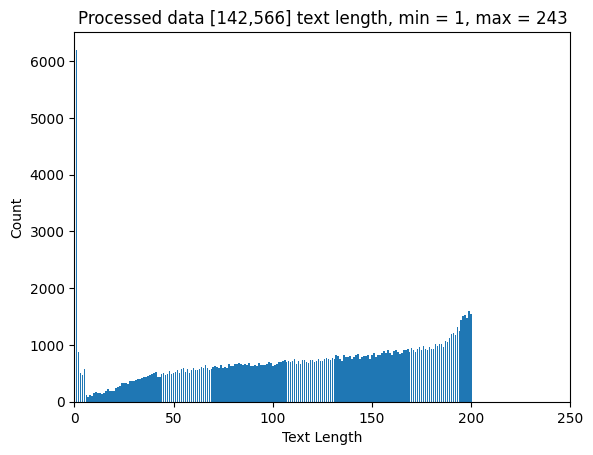

In [17]:
lengths = [len(row['text']) for _, row in splitted_big_df.iterrows()]
counter = Counter(lengths)

plt.bar(counter.keys(), counter.values())
plt.xlim(0, 250)
plt.xlabel("Text Length")
plt.ylabel("Count")
plt.title(f"Processed data [{len(lengths):,}] text length, min = {min(counter)}, max = {max(counter)}")
plt.show()

In [18]:
splitted_big_df['text'] = splitted_big_df['text'].apply(clean_text)
ready_splitted_big_df = splitted_big_df[splitted_big_df['text'].str.len() >= min_len]
print(f"Number of ready_splitted_big_df [{len(ready_splitted_big_df):,} / {len(splitted_big_df):,}]")

Number of ready_splitted_big_df [118,213 / 142,566]


In [19]:
sampled = ready_splitted_big_df.sample(n=3)["text"].to_list()
for s in sampled:
    print(f"- {s}")

- историки начали заниматься более глубоким изучением истории своих стран в годы второй мировой войны восполняли пробелы
- грозит обратить вспять положительные тенденции которые наметились к  году
- c правительствам следует стремиться собирать информацию о предприятиях которые производят или удаляютрециркулируют опасные отходы


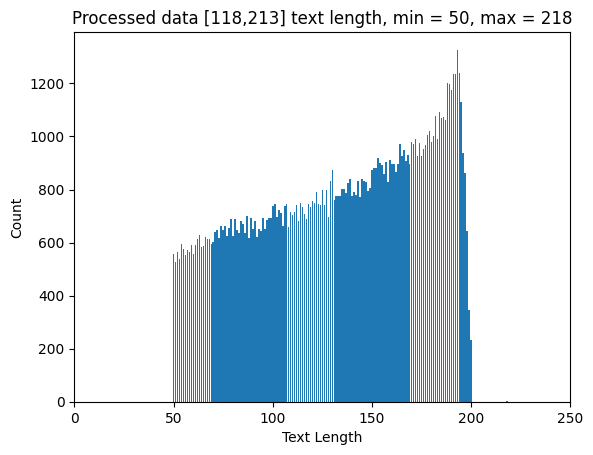

In [20]:
lengths = [len(row['text']) for _, row in ready_splitted_big_df.iterrows()]
counter = Counter(lengths)

plt.bar(counter.keys(), counter.values())
plt.xlim(0, 250)
plt.xlabel("Text Length")
plt.ylabel("Count")
plt.title(f"Processed data [{len(lengths):,}] text length, min = {min(counter)}, max = {max(counter)}")
plt.show()

In [21]:
print(f"Ready df: {len(ready_df):,}")
print(f"Ready splitted big df: {len(ready_splitted_big_df):,}")

Ready df: 253,263
Ready splitted big df: 118,213


In [22]:
db_df = pd.concat([ready_df, ready_splitted_big_df], ignore_index=True)
print(f"Number of db_texts: {len(db_df):,} / {len(df):,}")

Number of db_texts: 371,476 / 462,754


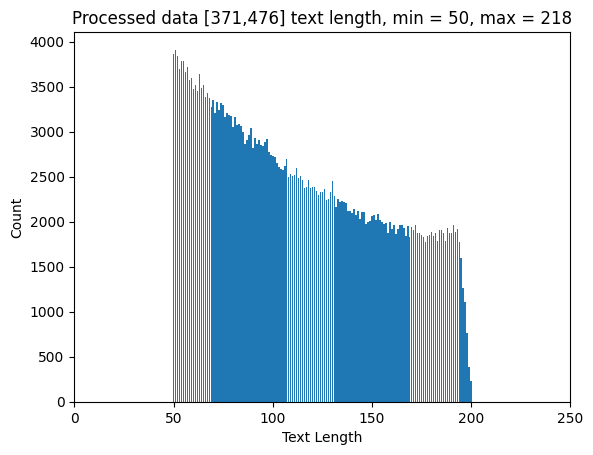

In [23]:
lengths = [len(row['text']) for _, row in db_df.iterrows()]
counter = Counter(lengths)

plt.bar(counter.keys(), counter.values())
plt.xlim(0, 250)
plt.xlabel("Text Length")
plt.ylabel("Count")
plt.title(f"Processed data [{len(lengths):,}] text length, min = {min(counter)}, max = {max(counter)}")
plt.show()

In [24]:
db_df.to_json(
    "data/db_docs.json", 
    orient="records", 
    force_ascii=False, 
    indent=2,
)